# DL challenge

In [19]:
# importing the Keras libraries and packages
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import csv
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
class_names = [
    "Black_spiny_tailed_iguana",
    "Brown_anole",
    "Cuban_knight_anole",
    "Desert_iguana",
    "Green_anole",
    "Green_iguana",
    "Lesser_Antillean_iguana"
]

NUM_CLASSES = 7
IMG_SIZE = 64
HEIGHT_FACTOR = 0.2
WIDTH_FACTOR = 0.2

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(64, 64, 3),
    include_top=False,
    weights="imagenet"
)

model = tf.keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Set the parameters for your data
batch_size = 32
image_size = (64, 64)
validation_split = 0.2

# Create the training dataset from the 'train' directory
train_ds = image_dataset_from_directory(
    directory='./train',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=image_size,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Create the validation dataset from the 'train' directory
validation_ds = image_dataset_from_directory(
    directory='./train',
    labels='inferred',
    label_mode='int',
    batch_size=batch_size,
    image_size=image_size,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Ensure the dataset can generate enough batches (so keep on generating when needed)
train_ds = train_ds.repeat()
validation_ds = validation_ds.repeat()

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.


In [17]:
model.fit(train_ds,
            validation_data = validation_ds,
            steps_per_epoch = 100,
            validation_steps = 20, # we have a .20 validation split, so we'll use 80% less batches for validation
            epochs = 20
          )

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 530ms/step - accuracy: 0.3801 - loss: 1.6072 - val_accuracy: 0.4211 - val_loss: 1.8779
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 495ms/step - accuracy: 0.8879 - loss: 0.3679 - val_accuracy: 0.3876 - val_loss: 2.9346
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 531ms/step - accuracy: 0.8722 - loss: 0.3831 - val_accuracy: 0.4245 - val_loss: 3.3179
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 584ms/step - accuracy: 0.9200 - loss: 0.2502 - val_accuracy: 0.4463 - val_loss: 2.8670
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 514ms/step - accuracy: 0.9358 - loss: 0.2060 - val_accuracy: 0.4530 - val_loss: 3.2693
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 488ms/step - accuracy: 0.9397 - loss: 0.1690 - val_accuracy: 0.4379 - val_loss: 3.3162
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 47s 474ms/step - accuracy: 0.9526 - loss: 0.1283 - val_accuracy: 0.4664 - val_loss: 3.4346
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 557ms/step - accuracy: 0.9244 - loss: 0

In [20]:
# aparte eval-validatieset, niet herhalen
validation_eval_ds = image_dataset_from_directory(
    directory='./train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(64, 64),
    validation_split=0.2,
    subset='validation',
    seed=123,
    shuffle=False
)

# echte labels verzamelen
y_true = np.concatenate([y.numpy() for _, y in validation_eval_ds])

# voorspellingen maken
y_pred_probs = model.predict(validation_eval_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# confusion matrix
cm = tf.math.confusion_matrix(
    y_true, y_pred, num_classes=NUM_CLASSES
).numpy()

# meest verwarde klasse-paren zoeken
most_confused = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            most_confused.append((class_names[i], class_names[j], int(cm[i, j])))

most_confused = sorted(most_confused, key=lambda x: x[2], reverse=True)

print("Top 10 most confused:")
for actual, predicted, count in most_confused[:10]:
    print(f"{actual} -> {predicted}: {count}")

Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Top 10 most confused:
Lesser_Antillean_iguana -> Desert_iguana: 7
Green_iguana -> Desert_iguana: 4
Lesser_Antillean_iguana -> Cuban_knight_anole: 4
Lesser_Antillean_iguana -> Green_iguana: 4
Green_iguana -> Black_spiny_tailed_iguana: 3
Green_iguana -> Lesser_Antillean_iguana: 2
Lesser_Antillean_iguana -> Black_spiny_tailed_iguana: 2
Lesser_Antillean_iguana -> Green_anole: 2
Lesser_Antillean_iguana -> Brown_anole: 1


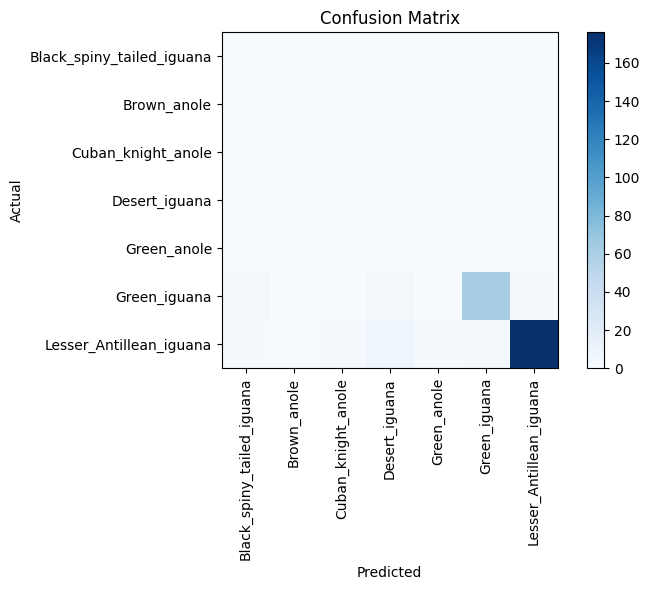

In [21]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(NUM_CLASSES), class_names, rotation=90)
plt.yticks(range(NUM_CLASSES), class_names)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()